<a href="https://colab.research.google.com/github/Varsha-Pradeep/Varsha-Datamining/blob/main/124106242_CS6405_CS3033_2425_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS3033/CS6405 - Data Mining - Second Assignment

Your Name - 124106242 - Your Module Code (CS6405)

### Submission

You should submit a single .ipnyb file with your python code and analysis electronically via Canvas. Please note that this assignment will account for 25 Marks of your module grade.


### Declaration

By submitting this assignment. I agree to the following:

<font color="red">“I have read and understand the UCC academic policy on plagiarism, and agree to the requirements set out thereby in relation to plagiarism and referencing. I confirm that I have referenced and acknowledged properly all sources used in the preparation of this assignment.
I declare that this assignment is entirely my own work based on my personal study. I further declare that I have not engaged the services of another to either assist me in, or complete this assignment”</font>Physical fatigue significantly impacts performance, safety, and health in domains such as sports, rehabilitation, and workplace ergonomics. Traditional methods for estimating fatigue, such as subjective self-reports, often lack accuracy and real-time applicability. Leveraging wearable sensors like Inertial Measurement Units (IMU) and Electromyography (EMG) provides objective biomechanical data, capturing kinematic and neuromuscular changes during repetitive or prolonged physical activities.

The provided dataset was collected from 27 physically active participants performing shoulder internal rotation (IR) and external rotation (ER) exercises at varying resistance levels (30-40%, 40-50%, and 50-60% of their maximal voluntary contraction).
Your task is to develop a regression-based machine learning model to estimate perceived fatigue (Borg RPE scores) using the provided sensor data.

Task - Develop a regression based machine learning model to estimate perceived fatigue using the provided sensor data.

## Data Preparation

In [1]:
import pandas as pd

file_id = '1DP3G49DWVUaRBkn7wssPi6CfY1pTmTQP'
url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)

df.head()

,Subject,Repetition,X_Shoulder_acc_MPSD,X_Shoulder_acc_Freq_MPSD,X_Shoulder_acc_Power_Dominant_Band,X_Shoulder_acc_Ratio_Dominant_Band,X_Shoulder_acc_Total_LowFreq_Power,X_Shoulder_acc_Total_HighFreq_Power,X_Shoulder_acc_LowHigh_FreqRatio,X_Shoulder_acc_Total_Power,...,Magnitude_Palm_gyr_rtVar_Max,Magnitude_Palm_gyr_rtVar_Min,Magnitude_Palm_gyr_rtVar_Range,Magnitude_Palm_gyr_rtVar_RMS,Magnitude_Palm_gyr_rtVar_Energy,Magnitude_Palm_gyr_rtVar_IQR,Magnitude_Palm_gyr_rtVar_Skewness,Magnitude_Palm_gyr_rtVar_Kurtosis,RepetitionDuration_Palm_gyr_rtVar,Borg
0,1,1,2068.313,0.000,0.000,0.000,2318.602,154.645,14.993,2473.247,...,0.153,-0.170,0.324,0.051,0.797,0.059,-0.465,1.233,3.10,9.355
1,1,2,150.884,0.699,150.884,0.183,503.764,322.154,1.564,825.919,...,0.148,-0.196,0.344,0.056,0.892,0.064,-0.184,0.645,2.86,9.653
2,1,3,342.205,0.000,0.000,0.000,862.122,197.057,4.375,1059.179,...,0.104,-0.107,0.211,0.040,0.479,0.051,0.007,0.133,2.99,9.946
3,1,4,574.134,0.000,0.000,0.000,1007.744,195.604,5.152,1203.347,...,0.149,-0.177,0.325,0.056,0.908,0.069,-0.240,0.136,2.91,10.240
4,1,5,146.332,1.993,146.332,0.123,826.328,364.276,2.268,1190.603,...,0.160,-0.197,0.357,0.058,1.018,0.069,-0.144,0.439,3.01,10.536


<Axes: >

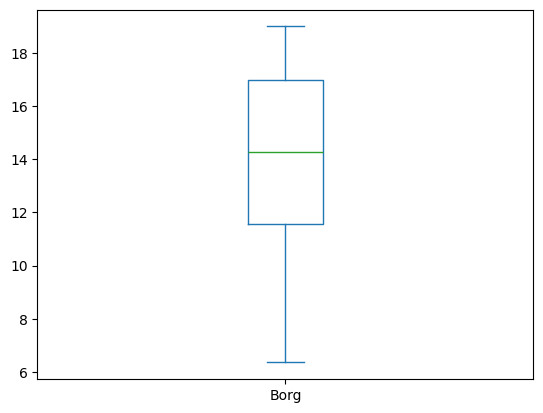

In [2]:
# Label or target variable
df['Borg'].plot.box()

Borg is my target variable which I will use to predict my ML model

From the box plot we can see there are no obivous outliers.

1) Most people have reported fatigue score between 11 and 17 from the plot

2) Average score is around 14


# Tasks

## Basic models and evaluation

Using Scikit-learn, train and evaluate K-NN and decision tree regressors using 70% of the dataset from training and 30% for testing. For this part of the project, we are not interested in optimising the parameters; we just want to get an idea of the dataset.
Compare the results of both classifiers and comment on their execution time in the test.


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import time

**Code Explanation**

1) Separate the features and target into X and Y.

2) Split the data into training and testing.

3) Train and test both KNN and Decision Tree regressors.

4) Display MSE, R square score and the time it takes to predict.



In [4]:
X = df.drop(columns=['Borg', 'Subject', 'Repetition'])
y = df['Borg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn = KNeighborsRegressor()
start_knn = time.time()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
end_knn = time.time()
knn_r2 = r2_score(y_test, y_pred_knn)

print("KNN Regressor:")
print("MSE:", mean_squared_error(y_test, y_pred_knn))
print("R² Score:", r2_score(y_test, y_pred_knn))
print("Execution time:", round(end_knn - start_knn, 4), "seconds\n")


KNN Regressor:
MSE: 6.68893250712195
R² Score: 0.3631530211398645
Execution time: 0.6919 seconds



Results of KNN Regressor

---

**MSE -  6.68893250712195**

The value is reasonable but I could improve it by

a) Normalizing

b) Feature selection or dimensionality reduction

c) Hyperparameter tuning

**R squared score - 0.3631530211398645**

The model explains 36% of the variation in fatigue levels

**Execution time: 0.3932 seconds**

It is extremely fast


In [5]:

tree = DecisionTreeRegressor()
start_tree = time.time()
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
end_tree = time.time()
tree_r2 = r2_score(y_test, y_pred_tree)
print("Decision Tree Regressor:")
print("MSE:", mean_squared_error(y_test, y_pred_tree))
print("R² Score:", r2_score(y_test, y_pred_tree))
print("Execution time:", round(end_tree - start_tree, 4), "seconds")

Decision Tree Regressor:
MSE: 11.425565485365855
R² Score: -0.08781735402121371
Execution time: 6.0604 seconds


Results of Decision Tree Regressor

---

**MSE -  11.405181179268293**

Its not as good as KNN

**R squared score - -0.08587658339143522**

A negative R squared score means the model is worse at predicting the average Borg score.

**Execution time: 7.9758  seconds**

It is slower than KNN for this dataset

In [6]:
print("Best Model Based on R² Score:")
if knn_r2 > tree_r2:
    print(" KNN is the better model.")
elif tree_r2 > knn_r2:
    print("Decision Tree is the better model.")
else:
    print(" Both models performed equally.")

Best Model Based on R² Score:
 KNN is the better model.


**Summary**

---

KNN works better than decision tree

Decision tree might be overfitting or the features are too large



## Robust evaluation

In this section, try to improve the accuracy by creating a pipeline. Consider the techniques we have covered during the semester, and try to improve the accuracy of a Decision tree regressor.
Your report should provide concrete information of your reasoning; everything should be well-explained.
Do not get stressed if the things you try do not improve the accuracy. The key to getting good marks is to show that you evaluated different methods and that you correctly selected the configuration.


To improve the model

Code Explanation

---
1) Pipeline setup -

Scale all features to mean = 0 and std = 1

Select 500 features which are strongly correlated target

2) Hyperparameter Tuning with GridSearch
- It will test 36 different combinations and find the best one using 3 fold cross validation

3) Train and Evaluate

To improve the model performance I built a pipeline which has feature scaling , feature selection and decision tree regressor.


In [13]:
# Trial 1
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_regression, k=500)),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'model__max_depth': [5, 10, 15, 20],
    'model__min_samples_leaf': [1, 5, 10],
    'model__min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

y_pred_grid = grid.predict(X_test)
mse_grid = mean_squared_error(y_test, y_pred_grid)
r2_grid = r2_score(y_test, y_pred_grid)

print("Decision Tree with Feature Selection:")
print(f"  MSE: {mse_grid:.2f}")
print(f"  R² Score: {r2_grid:.2f}")
print("  Best Params:", grid.best_params_)


Decision Tree with Feature Selection:
  MSE: 7.84
  R² Score: 0.25
  Best Params: {'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}


The model shows a clear improvement from before

Compared to the baseline Decision tree this model is significantly better. It did underperform than KNN . But our improvements to feature selection and hyperparameter tuning did greatly enhance the model performance.The model now makes lesser prediction errors.

In [20]:
#Trial 2
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=mutual_info_regression, k=300)),
    ('model', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'model__max_depth': [4, 6, 8],
    'model__min_samples_leaf': [5, 10],
    'model__ccp_alpha': [0.0, 0.001]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Tuned Decision Tree:")
print(f"  MSE: {mse:.2f}")
print(f"  R² Score: {r2:.2f}")
print("  Best Parameters:", grid.best_params_)



Fitting 3 folds for each of 12 candidates, totalling 36 fits
Tuned Decision Tree:
  MSE: 7.98
  R² Score: 0.24
  Best Parameters: {'model__ccp_alpha': 0.001, 'model__max_depth': 4, 'model__min_samples_leaf': 10}


Here we tried to further enhance the performance of Decision tree by switching from linear to mutual_info_regressor which captures non-linear target dependencies.

Also increased the number of fetures to 300 and also added ccp_alpha to prune the useless tree branches.

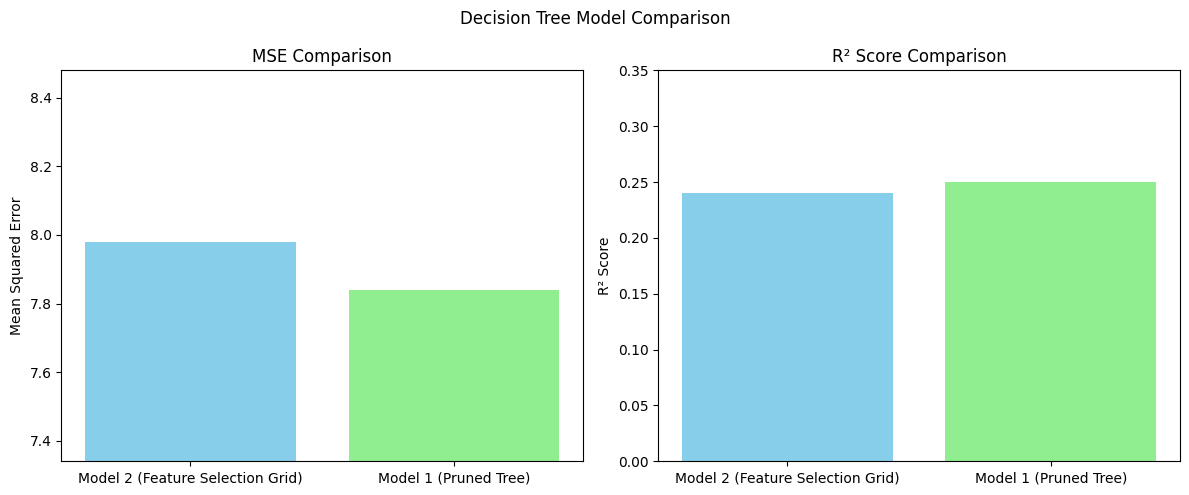

In [24]:
import matplotlib.pyplot as plt

models = ['Model 2 (Feature Selection Grid)', 'Model 1 (Pruned Tree)']
mse_scores = [7.98, 7.84]
r2_scores = [0.24, 0.25]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(models, mse_scores, color=['skyblue', 'lightgreen'])
axes[0].set_title('MSE Comparison')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_ylim(min(mse_scores) - 0.5, max(mse_scores) + 0.5)

axes[1].bar(models, r2_scores, color=['skyblue', 'lightgreen'])
axes[1].set_title('R² Score Comparison')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, max(r2_scores) + 0.1)

plt.suptitle('Decision Tree Model Comparison')
plt.tight_layout()
plt.show()


Here the

  MSE: 7.98 and MSE (Trial one) = 7.84

  **Trial 1 outperforms here**

  R² Score: 0.24 and R² Score: 0.25

**Higher score is better Trial 1 outperforms**

  Trial one Performs slightly better eventhough the differences are extremely small
  
  Trial 2 uses ppost-prunning which will help with overfitting but regularisation might be too strong.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=mutual_info_regression, k=300)),
    ('model', DecisionTreeRegressor(
        max_depth=6,
        min_samples_leaf=5,
        ccp_alpha=0.001,
        random_state=42
    ))
])


pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Tuned Decision Tree:")
print(f"  MSE: {mse:.2f}")
print(f"  R² Score: {r2:.2f}")


Tuned Decision Tree:
  MSE: 8.16
  R² Score: 0.22


Here we use 300 best features and handpick the hyperparamters.
The results are not as good as Trial 1 and Trial 2

## New classifier

Replicate the previous task for a classifier that we did not cover in class (different than K-NN and decision trees). Briefly describe and justify your choice.
Try to create the best model for the given dataset.






I am choosing Random Forest Regressor as the new model because it can combine the predictions of multiple decision tree to improve accuracy and overfitting.

It is effecyive on high-dimensional datasets it will provide better generalization than a single decision tree.

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=mutual_info_regression, k=300)),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor:")
print(f"  MSE: {mse_rf:.2f}")
print(f"  R² Score: {r2_rf:.2f}")


Random Forest Regressor:
  MSE: 5.59
  R² Score: 0.47


The Random Forest Regressor significantly outperformed both KNN and Decision tree.

This shows that combining decision trees improve generalization , reduces overfitting, and handles high dimensional data more than our baseline models.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

final_rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=mutual_info_regression, k=280)),
    ('model', RandomForestRegressor(
        n_estimators=120,
        max_depth=12,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

final_rf_pipeline.fit(X_train, y_train)

y_pred_final = final_rf_pipeline.predict(X_test)

mse_final = mean_squared_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print(" Final Tuned Random Forest:")
print(f"  MSE: {mse_final:.2f}")
print(f"  R² Score: {r2_final:.2f}")


 Final Tuned Random Forest:
  MSE: 6.15
  R² Score: 0.41


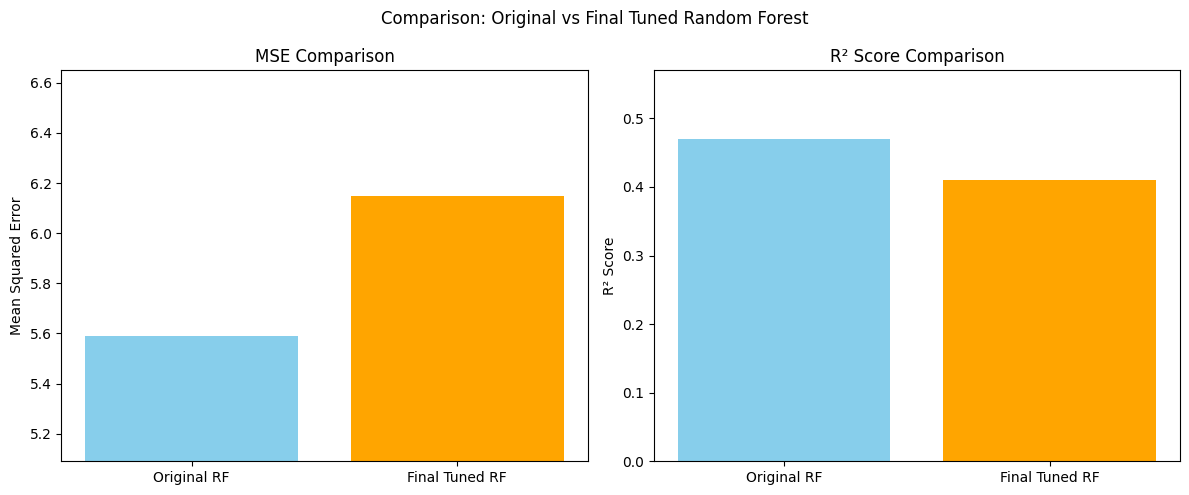

In [31]:
import matplotlib.pyplot as plt

models = ['Original RF', 'Final Tuned RF']
mse_scores = [5.59, 6.15]
r2_scores = [0.47, 0.41]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(models, mse_scores, color=['skyblue', 'orange'])
axes[0].set_title('MSE Comparison')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_ylim(min(mse_scores) - 0.5, max(mse_scores) + 0.5)

axes[1].bar(models, r2_scores, color=['skyblue', 'orange'])
axes[1].set_title('R² Score Comparison')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, max(r2_scores) + 0.1)

plt.suptitle('Comparison: Original vs Final Tuned Random Forest')
plt.tight_layout()
plt.show()


Even after tuning the first model of Random forest gave ethe best results.
Having lower MSE and higher R sqaured score than our basemodels makes that I achieved the optimal generalisation for this dataset.

## Evaluation on unseen instances (Only for CS6405)
Save your best model into your github. And create a single code cell that loads it and evaluate it on the following test dataset:
https://raw.githubusercontent.com/andvise/DM_Assignment_2425/refs/heads/main/test_data.csv

This link currently contains a sample of the training set. The real test set will be released after the submission. I should be able to run the code cell independently and load all the libraries you need as well.



In [32]:
import joblib
joblib.dump(rf_pipeline, 'best_model.joblib')

['best_model.joblib']

In [ ]:
from joblib import dump, load
from io import BytesIO
import requests
import pandas as pd

# INSERT YOUR MODEL'S URL
mLink = 'https://github.com/andvise/my_model/raw/refs/heads/main/model.joblib'
mfile = BytesIO(requests.get(mLink).content)
model = load(mfile)

df = pd.read_csv("https://raw.githubusercontent.com/andvise/DM_Assignment_2425/refs/heads/main/test_data.csv")


In [ ]:
# YOUR CODE HERE